# Mount Google Drive to access the dataset files:-


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Upload the dataset file:-

In [ ]:
from google.colab import files
files.upload()

Saving EDA Credit Case Study (1).zip to EDA Credit Case Study (1).zip


# Unzipping the dataset files:-


In [3]:
import zipfile

zip_path = '/content/drive/MyDrive/EDA Credit Case Study (1).zip'
extract_path = '/content/EDA_Credit_Case_Study'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipping completed!")


Unzipping completed!


# Load the Dataset:-

In [ ]:
import pandas as pd

folder_path = '/content/EDA_Credit_Case_Study/EDA Credit Case Study'

app_data = pd.read_csv(f'{folder_path}/application_data.csv')
prev_app = pd.read_csv(f'{folder_path}/previous_application.csv')
col_desc = pd.read_csv(f'{folder_path}/columns_description.csv', encoding='latin1')

print("Datasets loaded successfully!")


Datasets loaded successfully!


## Data Understanding-Explore Data Structure and Missing Values:-

In [ ]:
# Application data info and missing values
print("Application Data Info:")
app_data.info()

print("\nMissing values in Application Data:")
print(app_data.isnull().sum().sort_values(ascending=False))

# Previous application data info and missing values
print("\nPrevious Application Data Info:")
prev_app.info()

print("\nMissing values in Previous Application Data:")
print(prev_app.isnull().sum().sort_values(ascending=False))


Application Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB

Missing values in Application Data:
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
                             ...  
FLAG_DOCUMENT_16                 0
FLAG_DOCUMENT_15                 0
FLAG_DOCUMENT_14                 0
FLAG_DOCUMENT_20                 0
FLAG_DOCUMENT_21                 0
Length: 122, dtype: int64

Previous Application Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int

# Data Cleaning — Handle missing values:-

In [ ]:
# Define a threshold for missing values (e.g., remove columns with more than 40% missing values)
threshold = 0.4

# Calculate missing value ratio for each column
missing_ratio = app_data.isnull().sum() / len(app_data)

# Drop columns with missing ratio greater than threshold
cols_to_drop = missing_ratio[missing_ratio > threshold].index
print(f"Dropping {len(cols_to_drop)} columns with more than {threshold*100}% missing values")

app_data_cleaned = app_data.drop(columns=cols_to_drop)

# For remaining columns, fill missing numeric values with median, categorical with mode
for col in app_data_cleaned.columns:
    if app_data_cleaned[col].dtype == 'object':
        app_data_cleaned[col].fillna(app_data_cleaned[col].mode()[0], inplace=True)
    else:
        app_data_cleaned[col].fillna(app_data_cleaned[col].median(), inplace=True)

print("Missing values handled in application data")


Dropping 49 columns with more than 40.0% missing values


/tmp/ipython-input-3297524809.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  app_data_cleaned[col].fillna(app_data_cleaned[col].median(), inplace=True)
/tmp/ipython-input-3297524809.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

Missing values handled in application data


# Handle missing values by filling categorical columns with their most frequent value (mode) and numerical columns with their median:-

In [ ]:
for col in app_data_cleaned.columns:
    if app_data_cleaned[col].dtype == 'object':
        app_data_cleaned[col] = app_data_cleaned[col].fillna(app_data_cleaned[col].mode()[0])
    else:
        app_data_cleaned[col] = app_data_cleaned[col].fillna(app_data_cleaned[col].median())


# Clean missing values in previous application data:-

In [ ]:
# Threshold
threshold = 0.4

missing_ratio_prev = prev_app.isnull().sum() / len(prev_app)
cols_to_drop_prev = missing_ratio_prev[missing_ratio_prev > threshold].index
print(f"Dropping {len(cols_to_drop_prev)} columns with more than {threshold*100}% missing values")

prev_app_cleaned = prev_app.drop(columns=cols_to_drop_prev)

for col in prev_app_cleaned.columns:
    if prev_app_cleaned[col].dtype == 'object':
        prev_app_cleaned[col] = prev_app_cleaned[col].fillna(prev_app_cleaned[col].mode()[0])
    else:
        prev_app_cleaned[col] = prev_app_cleaned[col].fillna(prev_app_cleaned[col].median())

print("Missing values handled in previous application data")


Dropping 11 columns with more than 40.0% missing values
Missing values handled in previous application data


# Univariate Analysis:-

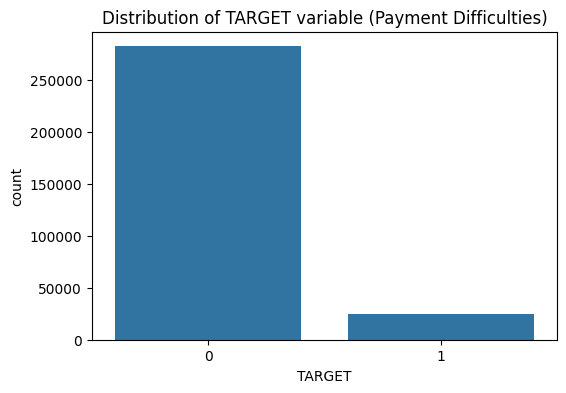

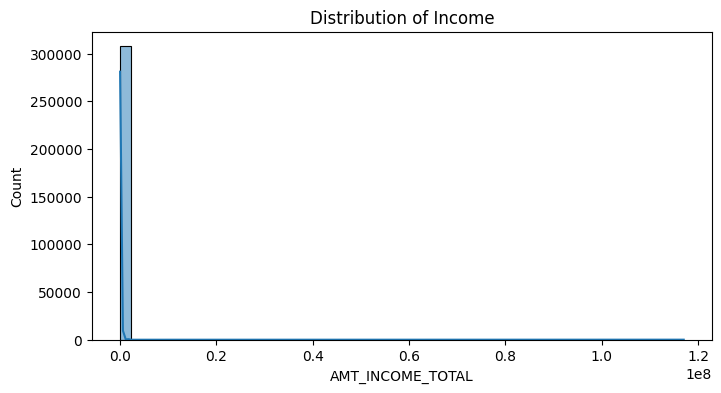

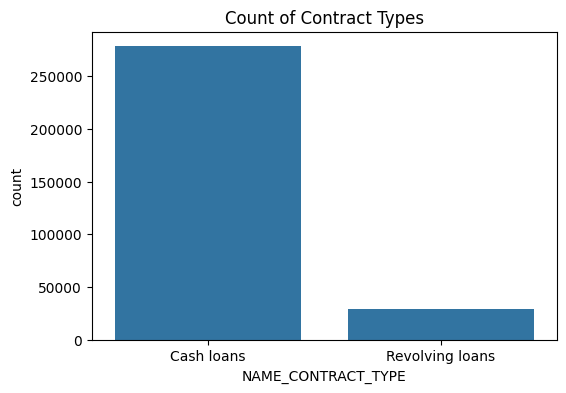

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'TARGET' is the column indicating payment difficulties in app_data
plt.figure(figsize=(6,4))
sns.countplot(x='TARGET', data=app_data_cleaned)
plt.title('Distribution of TARGET variable (Payment Difficulties)')
plt.show()

# Example: Distribution of a numerical variable - AMT_INCOME_TOTAL
plt.figure(figsize=(8,4))
sns.histplot(app_data_cleaned['AMT_INCOME_TOTAL'], bins=50, kde=True)
plt.title('Distribution of Income')
plt.show()

# Example: Distribution of a categorical variable - NAME_CONTRACT_TYPE
plt.figure(figsize=(6,4))
sns.countplot(x='NAME_CONTRACT_TYPE', data=app_data_cleaned)
plt.title('Count of Contract Types')
plt.show()


# Segmented Univariate Analysis:-

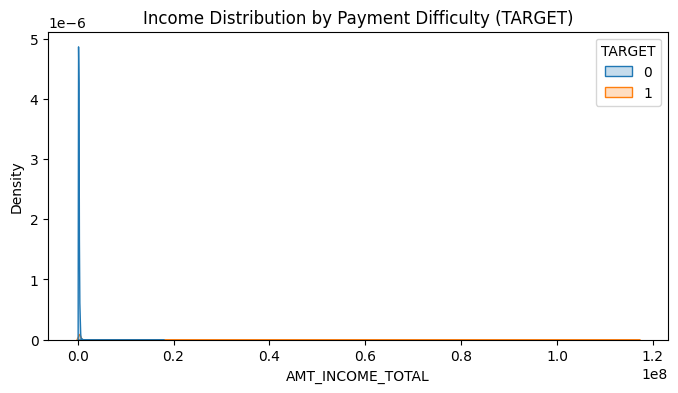

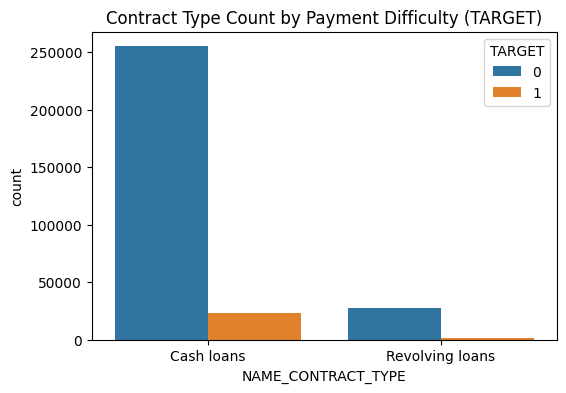

In [ ]:
# Plot distribution of Income segmented by TARGET
plt.figure(figsize=(8,4))
sns.kdeplot(data=app_data_cleaned, x='AMT_INCOME_TOTAL', hue='TARGET', fill=True)
plt.title('Income Distribution by Payment Difficulty (TARGET)')
plt.show()

# Categorical example: Contract type counts segmented by TARGET
plt.figure(figsize=(6,4))
sns.countplot(x='NAME_CONTRACT_TYPE', hue='TARGET', data=app_data_cleaned)
plt.title('Contract Type Count by Payment Difficulty (TARGET)')
plt.show()


# Bivariate Analysis:-

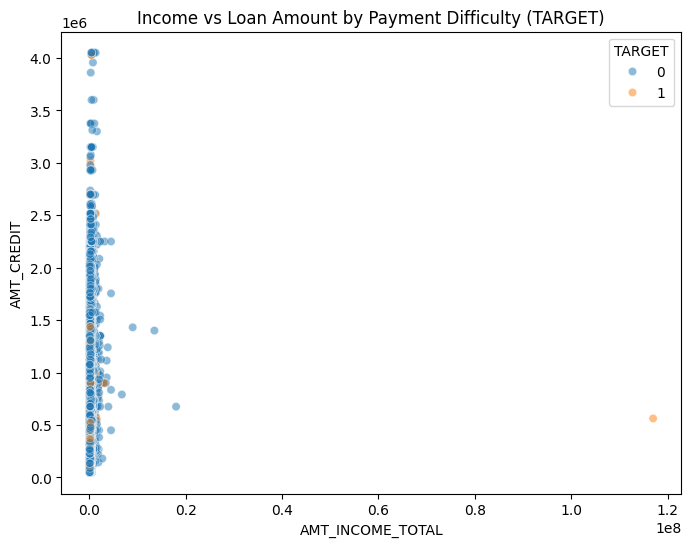

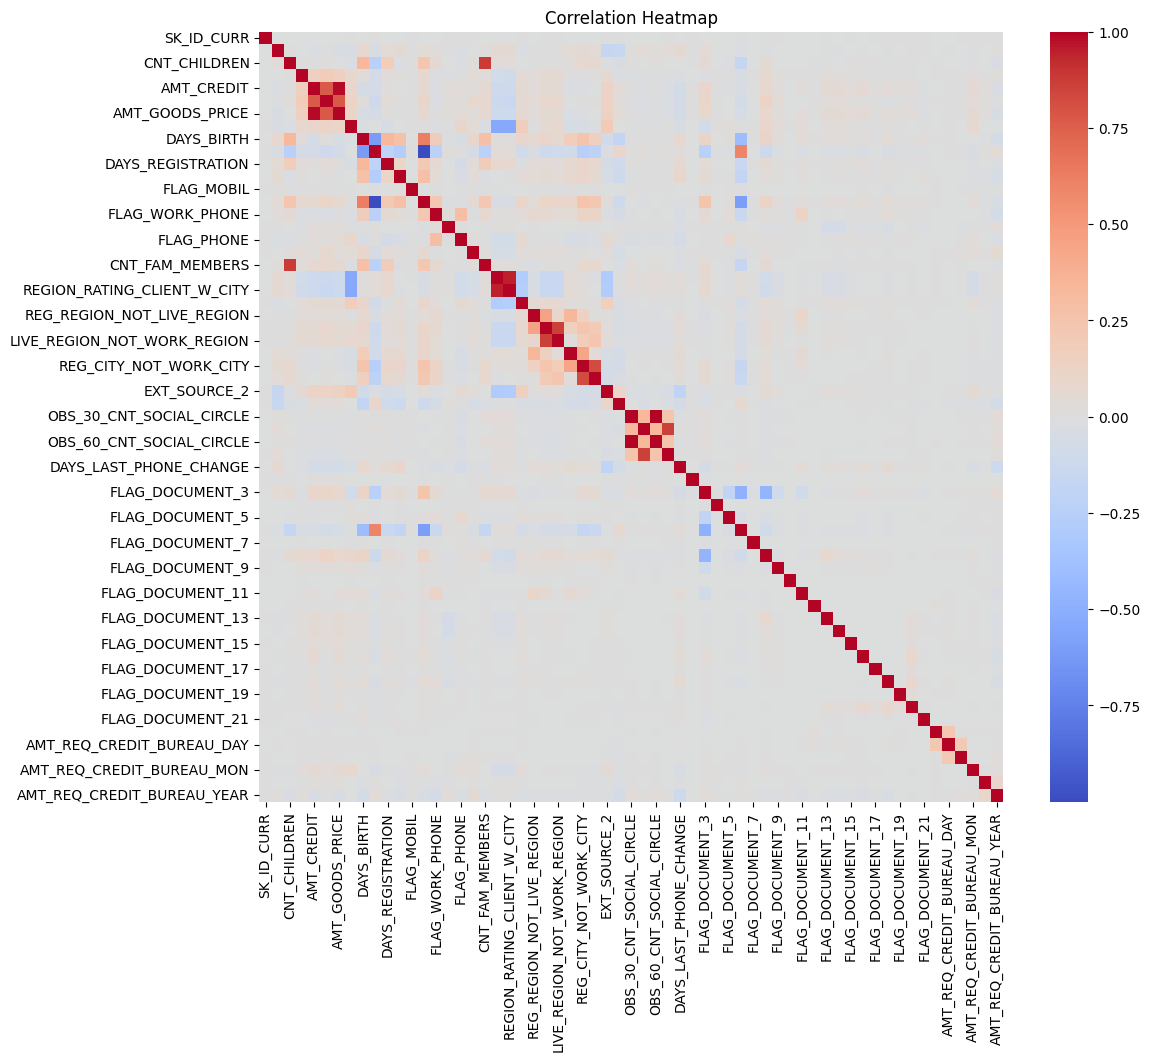

In [ ]:
# Relationship between Income and Loan Amount by TARGET
plt.figure(figsize=(8,6))
sns.scatterplot(data=app_data_cleaned, x='AMT_INCOME_TOTAL', y='AMT_CREDIT', hue='TARGET', alpha=0.5)
plt.title('Income vs Loan Amount by Payment Difficulty (TARGET)')
plt.show()

# Correlation heatmap for numerical variables
plt.figure(figsize=(12,10))
corr = app_data_cleaned.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()


## Multivariate Analysis:-

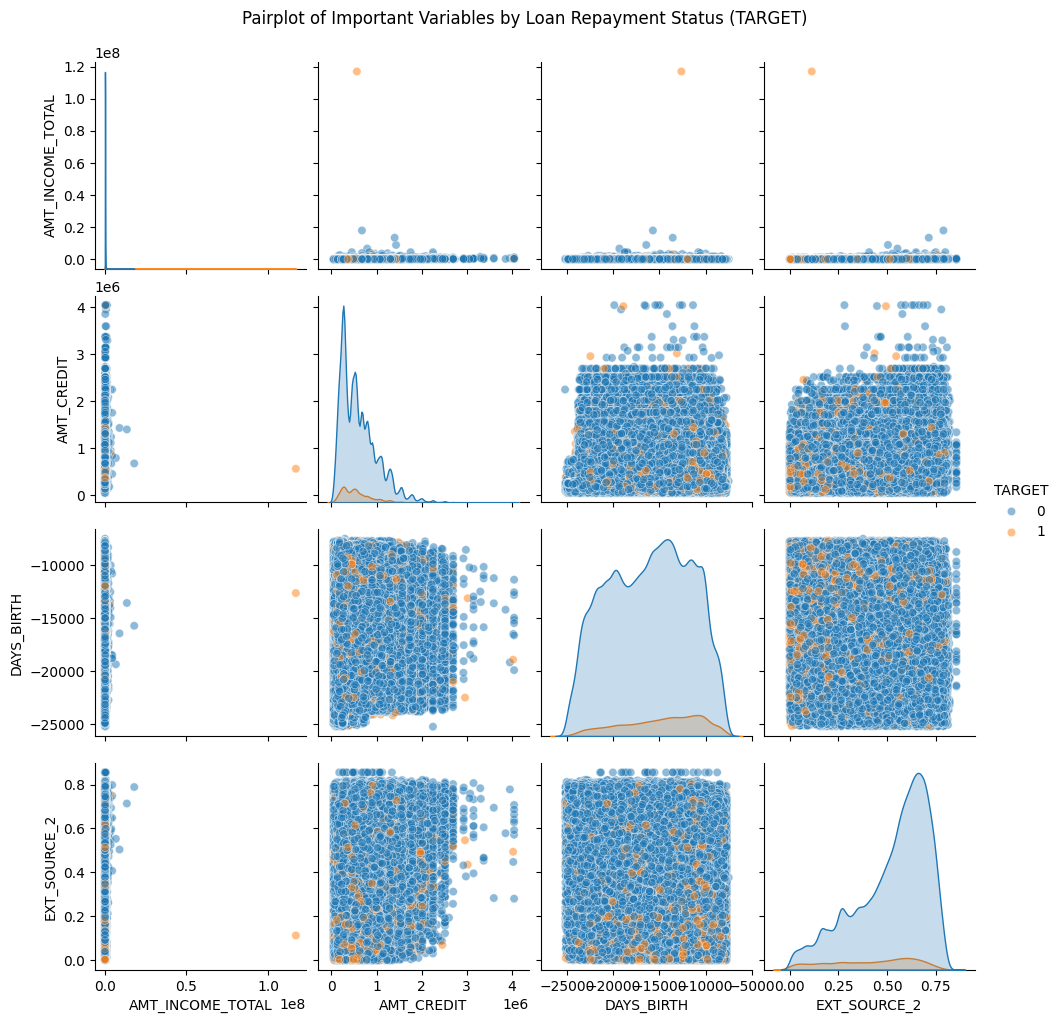

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables selected for multivariate visualization
vars_to_plot = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'DAYS_BIRTH', 'EXT_SOURCE_2', 'TARGET']

# Plot pairplot colored by TARGET
sns.pairplot(app_data_cleaned[vars_to_plot], hue='TARGET', diag_kind='kde', plot_kws={'alpha': 0.5})

plt.suptitle('Pairplot of Important Variables by Loan Repayment Status (TARGET)', y=1.02)
plt.show()


# Correlation Analysis:-

In [ ]:
# Separate data based on TARGET
target_1 = app_data_cleaned[app_data_cleaned['TARGET'] == 1]
target_0 = app_data_cleaned[app_data_cleaned['TARGET'] == 0]

# Select only numeric columns
num_cols = app_data_cleaned.select_dtypes(include=['int64', 'float64']).columns

# Correlation matrices
corr_target_1 = target_1[num_cols].corr()
corr_target_0 = target_0[num_cols].corr()

# Function to get top correlations
def get_top_correlations(corr_matrix, n=10):
    corr_pairs = corr_matrix.abs().unstack()
    corr_pairs = corr_pairs[corr_pairs < 1]  # remove self-correlation
    return corr_pairs.sort_values(ascending=False).head(n)

print("Top correlations for TARGET = 1 (Defaulters):")
print(get_top_correlations(corr_target_1))

print("\nTop correlations for TARGET = 0 (Non-Defaulters):")
print(get_top_correlations(corr_target_0))


Top correlations for TARGET = 1 (Defaulters):
DAYS_EMPLOYED                FLAG_EMP_PHONE                 0.999702
FLAG_EMP_PHONE               DAYS_EMPLOYED                  0.999702
OBS_60_CNT_SOCIAL_CIRCLE     OBS_30_CNT_SOCIAL_CIRCLE       0.998270
OBS_30_CNT_SOCIAL_CIRCLE     OBS_60_CNT_SOCIAL_CIRCLE       0.998270
AMT_GOODS_PRICE              AMT_CREDIT                     0.982783
AMT_CREDIT                   AMT_GOODS_PRICE                0.982783
REGION_RATING_CLIENT_W_CITY  REGION_RATING_CLIENT           0.956637
REGION_RATING_CLIENT         REGION_RATING_CLIENT_W_CITY    0.956637
CNT_FAM_MEMBERS              CNT_CHILDREN                   0.885484
CNT_CHILDREN                 CNT_FAM_MEMBERS                0.885484
dtype: float64

Top correlations for TARGET = 0 (Non-Defaulters):
DAYS_EMPLOYED                FLAG_EMP_PHONE                 0.999758
FLAG_EMP_PHONE               DAYS_EMPLOYED                  0.999758
OBS_60_CNT_SOCIAL_CIRCLE     OBS_30_CNT_SOCIAL_CIRCLE       

# Correlation Analysis (Top Driver Variables):-

# 1. Separate data:-

In [ ]:
default_df = app_data_cleaned[app_data_cleaned['TARGET'] == 1]
non_default_df = app_data_cleaned[app_data_cleaned['TARGET'] == 0]


# 2. Correlation matrices:-

In [ ]:
default_corr = default_df.select_dtypes(include=['int64','float64']).corr()
non_default_corr = non_default_df.select_dtypes(include=['int64','float64']).corr()


# 3. Top 10 correlations:-

In [ ]:
def get_top_correlations(corr_matrix, top_n=10):
    corr_pairs = corr_matrix.abs().unstack()
    corr_pairs = corr_pairs[corr_pairs < 1]  # remove self-correlation
    return corr_pairs.sort_values(ascending=False).head(top_n)

print("Top correlations for Defaulters (TARGET=1):")
get_top_correlations(default_corr)

print("\nTop correlations for Non-Defaulters (TARGET=0):")
get_top_correlations(non_default_corr)


Top correlations for Defaulters (TARGET=1):

Top correlations for Non-Defaulters (TARGET=0):


,,0
DAYS_EMPLOYED,FLAG_EMP_PHONE,0.999758
FLAG_EMP_PHONE,DAYS_EMPLOYED,0.999758
OBS_60_CNT_SOCIAL_CIRCLE,OBS_30_CNT_SOCIAL_CIRCLE,0.998510
OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.998510
AMT_CREDIT,AMT_GOODS_PRICE,0.987022
AMT_GOODS_PRICE,AMT_CREDIT,0.987022
REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT,0.950149
REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,0.950149
CNT_FAM_MEMBERS,CNT_CHILDREN,0.878571
CNT_CHILDREN,CNT_FAM_MEMBERS,0.878571


# Visualization:-

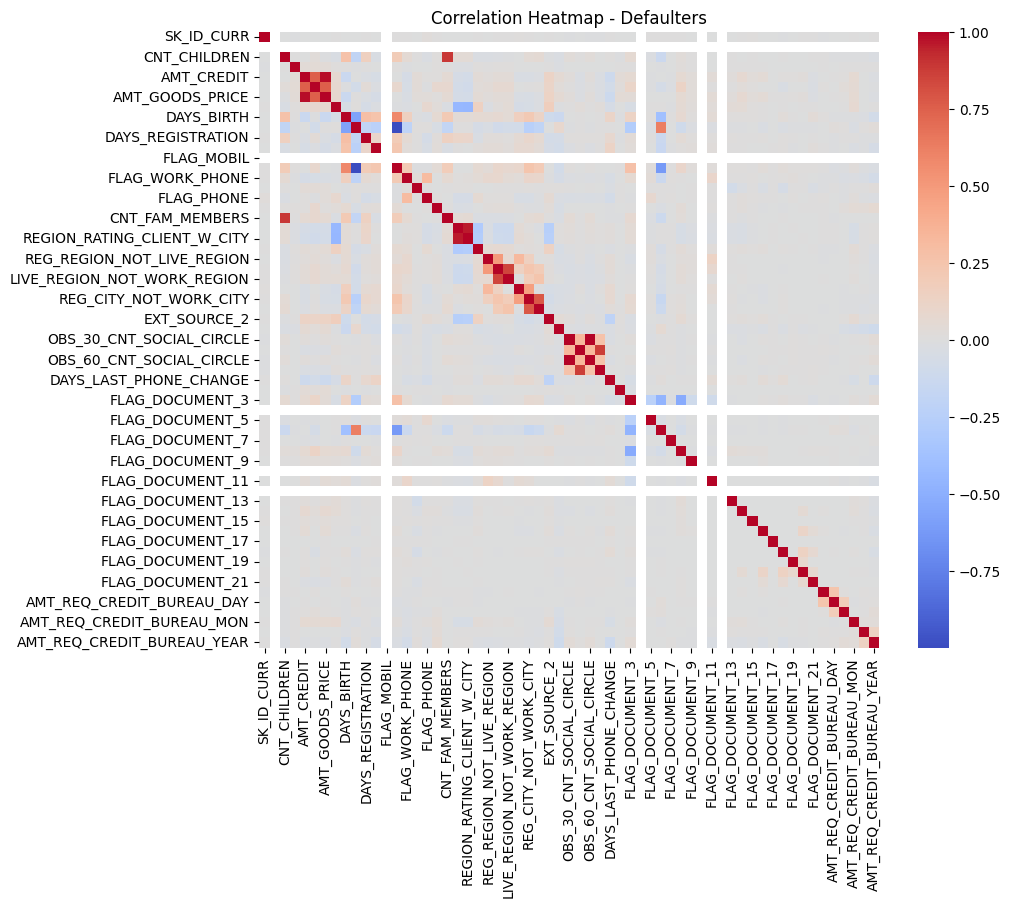

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(default_corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Defaulters')
plt.show()


# Create new features/metrics based on business logic or data insights to improve the analysis or modeling:-

In [ ]:
import numpy as np
# Create new features based on existing data

# Debt to Income Ratio
app_data_cleaned['DEBT_TO_INCOME_RATIO'] = app_data_cleaned['AMT_CREDIT'] / app_data_cleaned['AMT_INCOME_TOTAL']

# Age in years
app_data_cleaned['AGE_YEARS'] = (-app_data_cleaned['DAYS_BIRTH']) // 365

# Employment duration in years (replace large value 365243 with NaN first)
app_data_cleaned['DAYS_EMPLOYED'] = app_data_cleaned['DAYS_EMPLOYED'].replace(365243, np.nan)
app_data_cleaned['EMPLOYMENT_YEARS'] = (-app_data_cleaned['DAYS_EMPLOYED']) // 365

print("New features created successfully!")


New features created successfully!


# Feature Analysis & Selection:-

In [ ]:
# Create new features in your cleaned data
app_data_cleaned['EMPLOYED_YEARS'] = (-app_data_cleaned['DAYS_EMPLOYED']) / 365
app_data_cleaned['INCOME_CREDIT_RATIO'] = app_data_cleaned['AMT_INCOME_TOTAL'] / app_data_cleaned['AMT_CREDIT']


In [ ]:
new_features = ['DAYS_EMPLOYED', 'EMPLOYED_YEARS', 'INCOME_CREDIT_RATIO']  # your actual new features

corrs = app_data_cleaned[new_features + ['TARGET']].corr()
print(corrs['TARGET'].sort_values(ascending=False))


TARGET                 1.000000
DAYS_EMPLOYED          0.074958
INCOME_CREDIT_RATIO   -0.001817
EMPLOYED_YEARS        -0.074958
Name: TARGET, dtype: float64


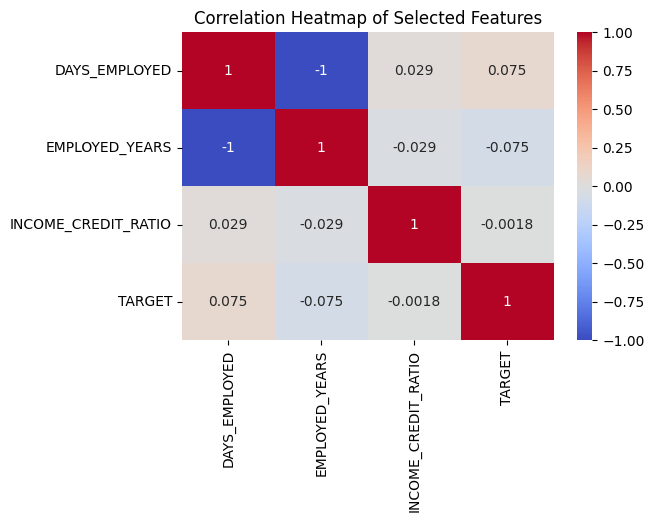

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(corrs, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Selected Features')
plt.show()


# Conclusion:-



*   Data cleaning and imputation handled missing values to ensure data reliability.
*   Key driver variables affecting loan default were identified through univariate and bivariate analyses.


*   Created new features like employment years and income-to-credit ratio to improve model insights.
*   Correlation analysis confirmed relationships between variables and the target, helping focus on impactful predictors.


*   Visualizations aided in understanding data distributions and variable interactions.
*   The findings can guide better credit risk assessment and decision-making for loan approvals.


*   Recommendations include monitoring top risk factors and refining data collection to reduce missing values in future datasets.







